Understanding the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Zomato-data-.csv to Zomato-data-.csv


In [ ]:
df = pd.read_csv("Zomato-data-.csv")

In [ ]:
print(df.shape)

(148, 7)


In [ ]:
print(df.columns)

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB
None


In [ ]:
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [ ]:
#remove duplicates
df.drop_duplicates(inplace=True)
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [ ]:
#check missing values
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [ ]:
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [ ]:
#Clean Cost Column
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',','')
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)']
)

In [ ]:
df.to_csv("cleaned_restaurant_data.csv", index=False)

EDA

In [ ]:
#total restaurants
print(df['name'])

0                      Jalsa
1             Spice Elephant
2            San Churro Cafe
3      Addhuri Udupi Bhojana
4              Grand Village
               ...          
143         Melting Melodies
144          New Indraprasta
145             Anna Kuteera
146                   Darbar
147            Vijayalakshmi
Name: name, Length: 148, dtype: object


In [ ]:
print(df['name'].nunique())

145


In [ ]:
#avg rating
print(df['rate'].mean())

3.6331081081081082


In [ ]:
#avg votes
print(df['votes'].mean())

264.81081081081084


In [ ]:
#Highest Rated Restaurants
top_rated = df.sort_values(
    by='rate',
    ascending=False
)

print(top_rated[['name','rate']].head(10))

                      name  rate
7                   Onesta   4.6
44                  Onesta   4.6
38       Empire Restaurant   4.4
86           Meghana Foods   4.4
52  Corner House Ice Cream   4.3
57                  Wamama   4.2
60           Peppy Peppers   4.2
81           Frozen Bottle   4.2
34                  Faasos   4.2
12        The Coffee Shack   4.2


In [ ]:
#most voted restaturants
popular = df.sort_values(
    by='votes',
    ascending=False
)

print(popular[['name','votes']].head(10))

                  name  votes
38   Empire Restaurant   4884
86       Meghana Foods   4401
7               Onesta   2556
44              Onesta   2556
65         Kabab Magic   1720
37     Szechuan Dragon   1647
54        Roving Feast   1047
2      San Churro Cafe    918
14     San Churro Cafe    918
67  Gustoes Beer House    868


Fake Review Detection Logic

In [ ]:
#high rating+low votes
df['suspicious_review']=(df['rate']>=4.5) & (df['votes']< 20)
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),suspicious_review
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,False
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,False
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,False
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,False
4,Grand Village,No,No,3.8,166,600,Buffet,False
...,...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining,False
144,New Indraprasta,No,No,3.3,0,150,Dining,False
145,Anna Kuteera,Yes,No,4.0,771,450,Dining,False
146,Darbar,No,No,3.0,98,800,Dining,False


In [ ]:
#High Rating + Low Votes
df['suspicious_1'] = (
    (df['rate'] > 4.5) &
    (df['votes'] < 20)
)

In [ ]:
#Very High Rating + Very Low Votes
df['suspicious_2'] = (
    (df['rate'] > 4.7) &
    (df['votes'] < 10)
)
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),suspicious_review,suspicious_1,suspicious_2
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,False,False,False
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,False,False,False
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,False,False,False
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,False,False,False
4,Grand Village,No,No,3.8,166,600,Buffet,False,False,False
...,...,...,...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining,False,False,False
144,New Indraprasta,No,No,3.3,0,150,Dining,False,False,False
145,Anna Kuteera,Yes,No,4.0,771,450,Dining,False,False,False
146,Darbar,No,No,3.0,98,800,Dining,False,False,False


In [ ]:
#High Rating + Low Cost + Low Votes
df['suspicious_3'] = (
    (df['rate'] > 4.5) &
    (df['votes'] < 20) &
    (df['approx_cost(for two people)'] < 300)
)
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),suspicious_review,suspicious_1,suspicious_2,suspicious_3
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,False,False,False,False
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,False,False,False,False
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,False,False,False,False
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,False,False,False,False
4,Grand Village,No,No,3.8,166,600,Buffet,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining,False,False,False,False
144,New Indraprasta,No,No,3.3,0,150,Dining,False,False,False,False
145,Anna Kuteera,Yes,No,4.0,771,450,Dining,False,False,False,False
146,Darbar,No,No,3.0,98,800,Dining,False,False,False,False


In [ ]:
#Risk Score System
df['risk_score'] = 0
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),suspicious_review,suspicious_1,suspicious_2,suspicious_3,risk_score
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,False,False,False,False,0
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,False,False,False,False,0
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,False,False,False,False,0
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,False,False,False,False,0
4,Grand Village,No,No,3.8,166,600,Buffet,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining,False,False,False,False,0
144,New Indraprasta,No,No,3.3,0,150,Dining,False,False,False,False,0
145,Anna Kuteera,Yes,No,4.0,771,450,Dining,False,False,False,False,0
146,Darbar,No,No,3.0,98,800,Dining,False,False,False,False,0


In [ ]:
# Create risk score column
df['risk_score'] = 0

# Add scores
df.loc[df['suspicious_1'], 'risk_score'] += 1
df.loc[df['suspicious_2'], 'risk_score'] += 2
df.loc[df['suspicious_3'], 'risk_score'] += 1

# Check results
df[['name', 'risk_score']].head()

,name,risk_score
0,Jalsa,0
1,Spice Elephant,0
2,San Churro Cafe,0
3,Addhuri Udupi Bhojana,0
4,Grand Village,0


In [ ]:
def category(score):

    if score >= 3:
        return "High Risk"

    elif score >= 1:
        return "Medium Risk"

    else:
        return "Normal"

df['risk_category'] = df['risk_score'].apply(category)

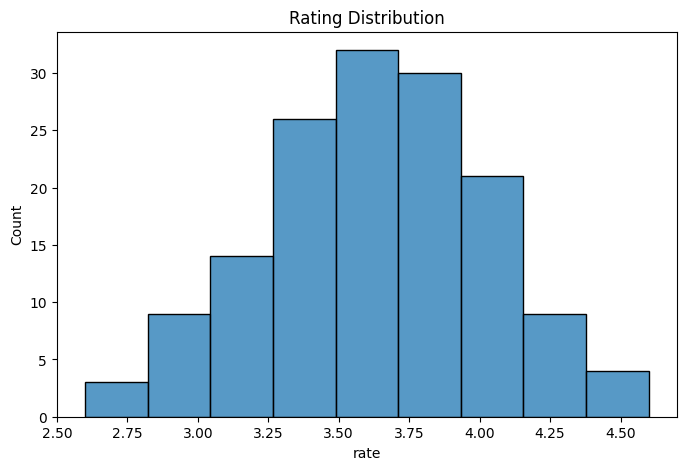

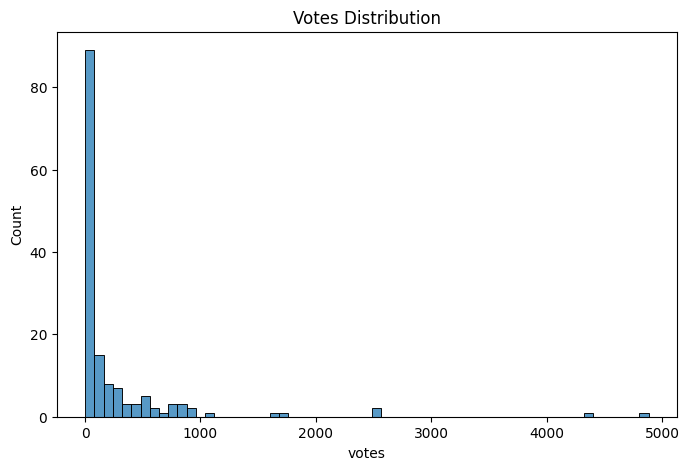

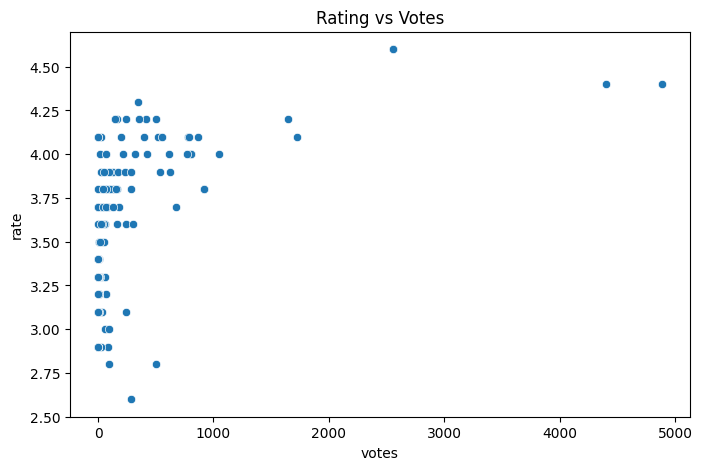

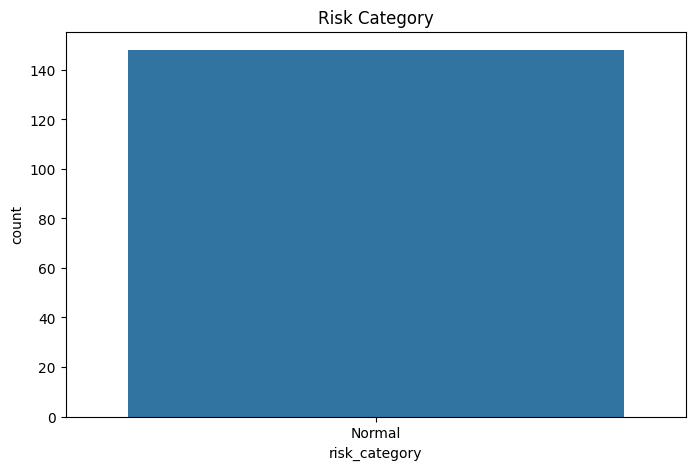

In [ ]:

# Rating Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['rate'])

plt.title("Rating Distribution")

plt.show()

# Votes Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['votes'])

plt.title("Votes Distribution")

plt.show()

# Rating vs Votes

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='votes',
    y='rate',
    data=df
)

plt.title("Rating vs Votes")

plt.show()

# Risk Category

plt.figure(figsize=(8,5))

sns.countplot(
    x='risk_category',
    data=df
)

plt.title("Risk Category")

plt.show()

In [ ]:
#total Restaurants

print(len(df))


148


In [ ]:
#Average Rating
df['rate'].mean()

np.float64(3.6331081081081082)

In [ ]:
#Average Votes

df['votes'].mean()

np.float64(264.81081081081084)

In [ ]:
#op Rated Restaurants
top_10 = df.sort_values(by='rate', ascending=False).head(10)

print(top_10)

                      name online_order book_table  rate  votes  \
7                   Onesta          Yes        Yes   4.6   2556   
44                  Onesta          Yes        Yes   4.6   2556   
38       Empire Restaurant          Yes         No   4.4   4884   
86           Meghana Foods          Yes         No   4.4   4401   
52  Corner House Ice Cream           No         No   4.3    345   
57                  Wamama          Yes        Yes   4.2    354   
60           Peppy Peppers           No         No   4.2    244   
81           Frozen Bottle          Yes         No   4.2    146   
34                  Faasos          Yes         No   4.2    415   
12        The Coffee Shack          Yes        Yes   4.2    164   

    approx_cost(for two people) listed_in(type)  suspicious_review  \
7                           600           Cafes              False   
44                          600           other              False   
38                          750           other     

In [ ]:
#Most Popular Restaurants
popular_restaurants = df.sort_values(
    by='votes',
    ascending=False
).head(10)

print(popular_restaurants)

                  name online_order book_table  rate  votes  \
38   Empire Restaurant          Yes         No   4.4   4884   
86       Meghana Foods          Yes         No   4.4   4401   
7               Onesta          Yes        Yes   4.6   2556   
44              Onesta          Yes        Yes   4.6   2556   
65         Kabab Magic          Yes         No   4.1   1720   
37     Szechuan Dragon          Yes         No   4.2   1647   
54        Roving Feast           No         No   4.0   1047   
2      San Churro Cafe          Yes         No   3.8    918   
14     San Churro Cafe          Yes         No   3.8    918   
67  Gustoes Beer House           No         No   4.1    868   

    approx_cost(for two people) listed_in(type)  suspicious_review  \
38                          750           other              False   
86                          600          Dining              False   
7                           600           Cafes              False   
44                        

In [ ]:
#Suspicious Restaurants
suspicious_restaurants = df[
    (df['rate'] > 4.5) &
    (df['votes'] < 20)
]

print(suspicious_restaurants)
print(
    "Total Suspicious Restaurants:",
    suspicious_restaurants.shape[0]
)

Empty DataFrame
Columns: [name, online_order, book_table, rate, votes, approx_cost(for two people), listed_in(type), suspicious_review, suspicious_1, suspicious_2, suspicious_3, risk_score, risk_category]
Index: []
Total Suspicious Restaurants: 0


In [ ]:
#. High Risk Restaurants
high_risk_restaurants = df[
    df['risk_category'] == 'High Risk'
]

print(high_risk_restaurants)
print(
    "Total High Risk Restaurants:",
    high_risk_restaurants.shape[0]
)

Empty DataFrame
Columns: [name, online_order, book_table, rate, votes, approx_cost(for two people), listed_in(type), suspicious_review, suspicious_1, suspicious_2, suspicious_3, risk_score, risk_category]
Index: []
Total High Risk Restaurants: 0


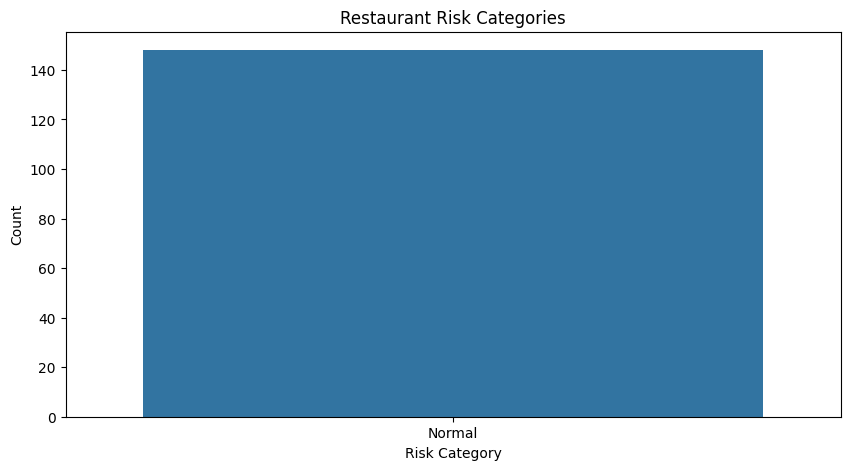

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='risk_category',
    data=df
)

plt.title("Restaurant Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

In [ ]:
df.to_csv(
    "restaurant_risk_analysis.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("restaurant_risk_analysis.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>